# AI NLP LLM Notes: TF-IDF for Search and Text Analytics

This notebook is a compact portfolio project that demonstrates how **TF-IDF** can be used to convert text into numerical features, inspect important terms, measure document similarity, and build a small search engine.

The goal is not only to show the API of `TfidfVectorizer`, but to connect the method to practical NLP workflows: feature engineering, model interpretability, search relevance, and the limitations that motivated modern embedding-based systems.

## What is TF-IDF?

**TF-IDF** stands for **Term Frequency-Inverse Document Frequency**. It is a weighting scheme that represents a document by assigning higher scores to words that are:

- frequent in a specific document, and
- relatively rare across the full document collection.

In other words, TF-IDF tries to capture which words are **distinctive** for a document, not just which words appear often.

At a high level:

\[
\text{TF-IDF}(t, d) = \text{TF}(t, d) \times \text{IDF}(t)
\]

where:

- **TF** measures how often term `t` appears in document `d`.
- **IDF** reduces the weight of terms that appear in many documents.

## Why do we need TF-IDF?

A simple **Bag of Words** representation counts how many times each word appears. This is useful, but it has an important weakness: common words can dominate the representation even when they do not describe the document well.

For example, words such as `data`, `system`, `model`, or `analysis` may appear frequently across many technical documents. Raw counts alone do not tell us whether a word is truly informative for a specific document.

TF-IDF improves on Bag of Words by down-weighting terms that appear across many documents and highlighting terms that better distinguish one document from another.

In [1]:
#!pip install matplotlib seaborn pandas scikit-learn
from collections import Counter
import re
import string

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
RANDOM_STATE = 42

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_theme(
    context="notebook",
    style="whitegrid",
    palette="deep",
    font="DejaVu Sans",
)

pd.set_option("display.max_colwidth", 120)

## Dataset

The corpus below contains short, realistic sentences from domains where NLP and machine learning are commonly applied: AI platforms, healthcare, finance, software engineering, cybersecurity, customer support, legal technology, and data science.

Each document is intentionally concise, but still specific enough to produce meaningful TF-IDF signals.

In [3]:
documents = [
    "A machine learning platform monitors model drift and retrains fraud detection pipelines when transaction patterns change.",
    "Clinical NLP systems extract medication names, dosages, and adverse events from unstructured electronic health records.",
    "Financial analysts use anomaly detection to identify suspicious trading behavior across high-volume market data.",
    "Software engineering teams rely on continuous integration tests to catch regressions before releasing production services.",
    "Customer support chatbots classify incoming tickets and route urgent billing issues to specialized service agents.",
    "Cybersecurity tools analyze authentication logs to detect compromised accounts and unusual access patterns.",
    "Data scientists compare feature importance scores to explain why a churn prediction model flags enterprise customers.",
    "Legal technology platforms summarize contracts and surface risky clauses for faster due diligence reviews.",
    "Healthcare researchers train language models to match patients with relevant clinical trials based on eligibility criteria.",
    "Recommendation engines personalize news feeds by ranking articles according to user interests and reading history.",
    "MLOps workflows track experiments, package models, and deploy reproducible inference services to cloud infrastructure.",
    "Risk management teams build stress testing dashboards to estimate portfolio exposure under volatile economic scenarios.",
]

document_ids = [f"DOC_{index:02d}" for index in range(1, len(documents) + 1)]

corpus_df = pd.DataFrame(
    {
        "document_id": document_ids,
        "text": documents,
    }
)

display(corpus_df)

,document_id,text
0,DOC_01,A machine learning platform monitors model drift and retrains fraud detection pipelines when transaction patterns ch...
1,DOC_02,"Clinical NLP systems extract medication names, dosages, and adverse events from unstructured electronic health records."
2,DOC_03,Financial analysts use anomaly detection to identify suspicious trading behavior across high-volume market data.
3,DOC_04,Software engineering teams rely on continuous integration tests to catch regressions before releasing production ser...
4,DOC_05,Customer support chatbots classify incoming tickets and route urgent billing issues to specialized service agents.
5,DOC_06,Cybersecurity tools analyze authentication logs to detect compromised accounts and unusual access patterns.
6,DOC_07,Data scientists compare feature importance scores to explain why a churn prediction model flags enterprise customers.
7,DOC_08,Legal technology platforms summarize contracts and surface risky clauses for faster due diligence reviews.
8,DOC_09,Healthcare researchers train language models to match patients with relevant clinical trials based on eligibility cr...
9,DOC_10,Recommendation engines personalize news feeds by ranking articles according to user interests and reading history.


## Text preprocessing

For this notebook, preprocessing is intentionally simple and transparent:

1. convert text to lowercase,
2. remove punctuation,
3. tokenize by splitting on whitespace.

In production NLP systems, preprocessing often depends on the model and use case. For example, a legal search engine may preserve section numbers and punctuation, while a social media classifier may normalize URLs, hashtags, and emojis.

In [4]:
def preprocess_text(text):
    """Lowercase text, remove punctuation, and tokenize by whitespace."""
    lowercase_text = text.lower()
    text_without_punctuation = lowercase_text.translate(
        str.maketrans("", "", string.punctuation)
    )
    tokens = text_without_punctuation.split()
    return tokens


corpus_df["tokens"] = corpus_df["text"].apply(preprocess_text)
corpus_df["preprocessed_text"] = corpus_df["tokens"].apply(" ".join)

display(corpus_df[["document_id", "preprocessed_text", "tokens"]])

,document_id,preprocessed_text,tokens
0,DOC_01,a machine learning platform monitors model drift and retrains fraud detection pipelines when transaction patterns ch...,"[a, machine, learning, platform, monitors, model, drift, and, retrains, fraud, detection, pipelines, when, transacti..."
1,DOC_02,clinical nlp systems extract medication names dosages and adverse events from unstructured electronic health records,"[clinical, nlp, systems, extract, medication, names, dosages, and, adverse, events, from, unstructured, electronic, ..."
2,DOC_03,financial analysts use anomaly detection to identify suspicious trading behavior across highvolume market data,"[financial, analysts, use, anomaly, detection, to, identify, suspicious, trading, behavior, across, highvolume, mark..."
3,DOC_04,software engineering teams rely on continuous integration tests to catch regressions before releasing production ser...,"[software, engineering, teams, rely, on, continuous, integration, tests, to, catch, regressions, before, releasing, ..."
4,DOC_05,customer support chatbots classify incoming tickets and route urgent billing issues to specialized service agents,"[customer, support, chatbots, classify, incoming, tickets, and, route, urgent, billing, issues, to, specialized, ser..."
5,DOC_06,cybersecurity tools analyze authentication logs to detect compromised accounts and unusual access patterns,"[cybersecurity, tools, analyze, authentication, logs, to, detect, compromised, accounts, and, unusual, access, patte..."
6,DOC_07,data scientists compare feature importance scores to explain why a churn prediction model flags enterprise customers,"[data, scientists, compare, feature, importance, scores, to, explain, why, a, churn, prediction, model, flags, enter..."
7,DOC_08,legal technology platforms summarize contracts and surface risky clauses for faster due diligence reviews,"[legal, technology, platforms, summarize, contracts, and, surface, risky, clauses, for, faster, due, diligence, revi..."
8,DOC_09,healthcare researchers train language models to match patients with relevant clinical trials based on eligibility cr...,"[healthcare, researchers, train, language, models, to, match, patients, with, relevant, clinical, trials, based, on,..."
9,DOC_10,recommendation engines personalize news feeds by ranking articles according to user interests and reading history,"[recommendation, engines, personalize, news, feeds, by, ranking, articles, according, to, user, interests, and, read..."


## Bag of Words baseline

Before using TF-IDF, it is helpful to inspect a raw count-based representation. Bag of Words ignores word order and only counts term occurrences.

This representation is simple and often useful, but it treats all terms as equally informative. A frequent but generic term can receive more weight than a rarer term that better captures the meaning of a document.

In [5]:
count_vectorizer = CountVectorizer(stop_words="english")
count_matrix = count_vectorizer.fit_transform(corpus_df["preprocessed_text"])
count_terms = count_vectorizer.get_feature_names_out()

term_counts = np.asarray(count_matrix.sum(axis=0)).ravel()
bow_summary = (
    pd.DataFrame({"term": count_terms, "raw_count": term_counts})
    .sort_values("raw_count", ascending=False)
    .head(15)
    .reset_index(drop=True)
)

display(bow_summary)

,term,raw_count
0,clinical,2
1,teams,2
2,detection,2
3,model,2
4,models,2
5,data,2
6,patterns,2
7,services,2
8,records,1
9,production,1


The Bag of Words summary is a useful starting point, but it mostly answers: **Which terms appear most often in the corpus?**

For document understanding and search, we usually need a more specific question: **Which terms are most important for each document compared with the rest of the corpus?**

## TF-IDF Vectorization

`TfidfVectorizer` combines token counting, vocabulary construction, and TF-IDF weighting in one estimator.

In this notebook, we experiment with three important parameters:

- `max_features`: keeps only the top vocabulary terms by frequency. This is useful for controlling dimensionality.
- `ngram_range`: controls whether the vectorizer uses single words, multi-word phrases, or both. `(1, 2)` means unigrams and bigrams.
- `stop_words`: removes common words that usually carry limited semantic value. Here we use the built-in English stop word list.

The vectorizer should be fit on the document corpus. New queries can then be transformed into the same feature space.

In [6]:
vectorizer_experiments = {
    "unigrams_all_terms": {
        "max_features": None,
        "ngram_range": (1, 1),
        "stop_words": None,
    },
    "unigrams_without_stop_words": {
        "max_features": None,
        "ngram_range": (1, 1),
        "stop_words": "english",
    },
    "unigrams_and_bigrams": {
        "max_features": None,
        "ngram_range": (1, 2),
        "stop_words": "english",
    },
    "portfolio_final_config": {
        "max_features": 45,
        "ngram_range": (1, 2),
        "stop_words": "english",
    },
}

experiment_rows = []

for experiment_name, parameters in vectorizer_experiments.items():
    experiment_vectorizer = TfidfVectorizer(**parameters)
    experiment_matrix = experiment_vectorizer.fit_transform(
        corpus_df["preprocessed_text"]
    )
    experiment_features = experiment_vectorizer.get_feature_names_out()
    preview_terms = ", ".join(experiment_features[:8])

    experiment_rows.append(
        {
            "experiment": experiment_name,
            "max_features": parameters["max_features"],
            "ngram_range": parameters["ngram_range"],
            "stop_words": parameters["stop_words"],
            "matrix_shape": experiment_matrix.shape,
            "vocabulary_size": len(experiment_features),
            "feature_preview": preview_terms,
        }
    )

experiments_df = pd.DataFrame(experiment_rows)
display(experiments_df)

,experiment,max_features,ngram_range,stop_words,matrix_shape,vocabulary_size,feature_preview
0,unigrams_all_terms,NaN,"(1, 1)",NaN,"(12, 153)",153,"access, according, accounts, across, adverse, agents, analysts, analyze"
1,unigrams_without_stop_words,NaN,"(1, 1)",english,"(12, 140)",140,"access, according, accounts, adverse, agents, analysts, analyze, anomaly"
2,unigrams_and_bigrams,NaN,"(1, 2)",english,"(12, 276)",276,"access, access patterns, according, according user, accounts, accounts unusual, adverse, adverse events"
3,portfolio_final_config,45.0,"(1, 2)",english,"(12, 45)",45,"access, clinical, data, detection, machine learning, management, management teams, market"


The experiment table shows how parameter choices change the feature space:

- removing stop words usually reduces noisy vocabulary,
- adding bigrams creates more expressive phrase features,
- limiting `max_features` keeps the matrix compact and easier to visualize.

For the remainder of the notebook, we use a balanced configuration: English stop word removal, unigrams plus bigrams, and a controlled feature limit.

In [7]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=45,
    ngram_range=(1, 2),
    stop_words="english",
    norm="l2",
)

tfidf_matrix = tfidf_vectorizer.fit_transform(corpus_df["preprocessed_text"])
feature_names = tfidf_vectorizer.get_feature_names_out()

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    index=corpus_df["document_id"],
    columns=feature_names,
)

print(f"TF-IDF matrix shape: {tfidf_df.shape[0]} documents x {tfidf_df.shape[1]} features")
display(tfidf_df.round(3).head())

TF-IDF matrix shape: 12 documents x 45 features


,access,clinical,data,detection,machine learning,management,management teams,market,market data,match,...,relevant,relevant clinical,rely,rely continuous,reproducible,reproducible inference,researchers,researchers train,services,teams
document_id,,,,,,,,,,,,,,,,,,,,,
DOC_01,0.0,0.000,0.000,0.376,0.438,0.0,0.0,0.000,0.000,0.0,...,0.0,0.0,0.000,0.000,0.0,0.0,0.0,0.0,0.000,0.000
DOC_02,0.0,0.652,0.000,0.000,0.000,0.0,0.0,0.000,0.000,0.0,...,0.0,0.0,0.000,0.000,0.0,0.0,0.0,0.0,0.000,0.000
DOC_03,0.0,0.000,0.461,0.461,0.000,0.0,0.0,0.536,0.536,0.0,...,0.0,0.0,0.000,0.000,0.0,0.0,0.0,0.0,0.000,0.000
DOC_04,0.0,0.000,0.000,0.000,0.000,0.0,0.0,0.000,0.000,0.0,...,0.0,0.0,0.325,0.325,0.0,0.0,0.0,0.0,0.279,0.279
DOC_05,0.0,0.000,0.000,0.000,0.000,0.0,0.0,0.000,0.000,0.0,...,0.0,0.0,0.000,0.000,0.0,0.0,0.0,0.0,0.000,0.000


The matrix above is the numerical representation of the corpus. Each row is a document, each column is a term or phrase, and each value is that term's TF-IDF weight in the document.

## Visualization: TF-IDF heatmap

A heatmap gives a quick visual overview of which terms are activated across the corpus. Since a full vocabulary can become wide, the plot below focuses on the highest average TF-IDF features.

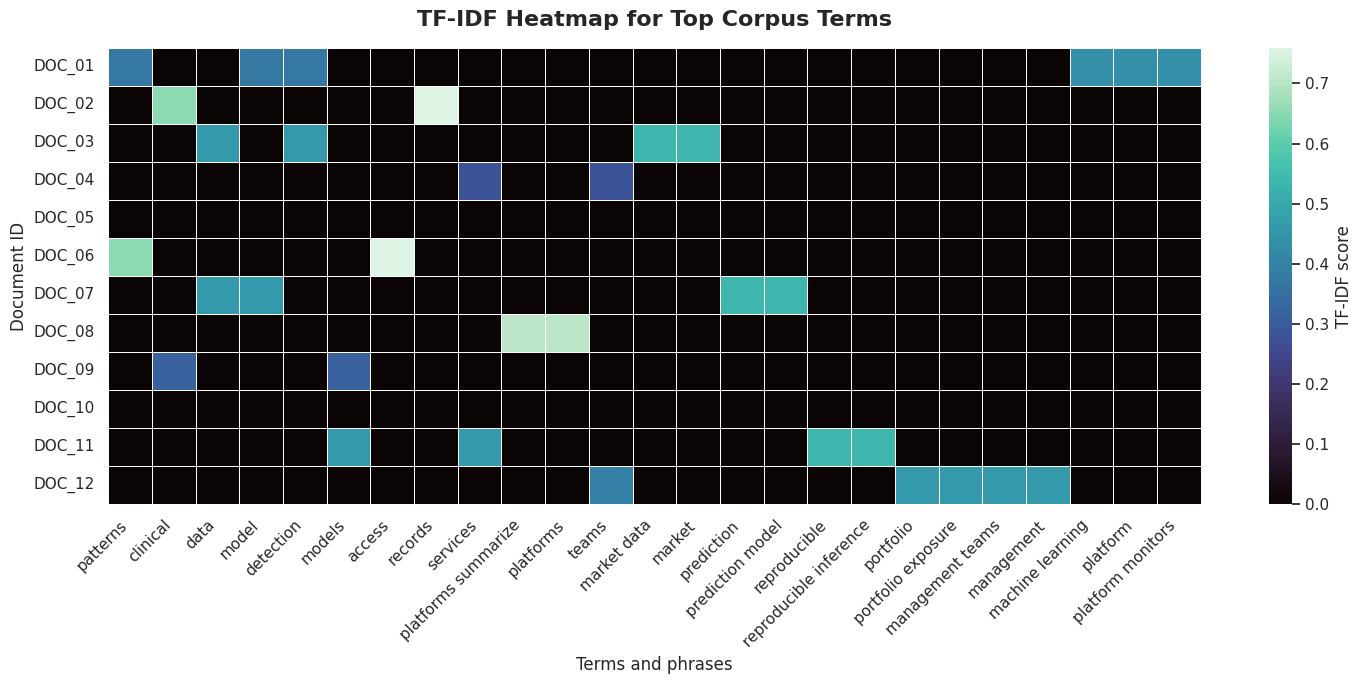

In [8]:
top_heatmap_terms = (
    tfidf_df.mean(axis=0)
    .sort_values(ascending=False)
    .head(25)
    .index
)

plt.figure(figsize=(15, 7))
ax = sns.heatmap(
    tfidf_df[top_heatmap_terms],
    cmap="mako",
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "TF-IDF score"},
)
ax.set_title("TF-IDF Heatmap for Top Corpus Terms", fontsize=16, weight="bold", pad=16)
ax.set_xlabel("Terms and phrases", fontsize=12)
ax.set_ylabel("Document ID", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Visualization: Highest scoring words

The next chart aggregates the maximum TF-IDF score each term receives in any document. This highlights terms that are especially distinctive somewhere in the corpus.

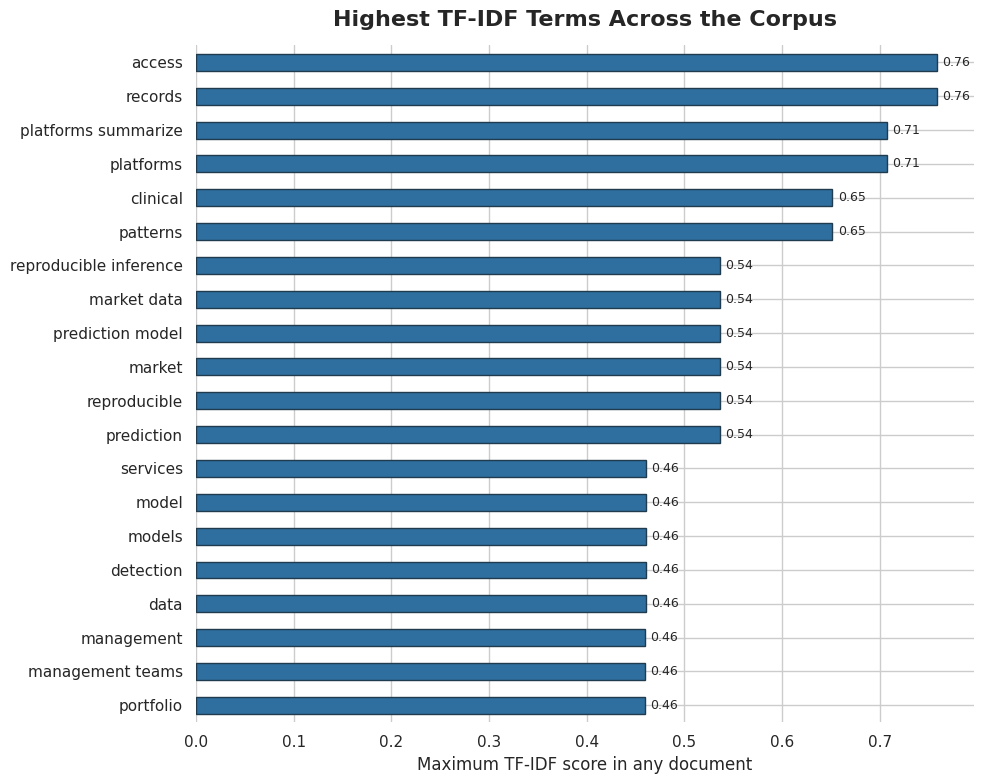

In [9]:
top_global_terms = (
    tfidf_df.max(axis=0)
    .sort_values(ascending=False)
    .head(20)
    .sort_values()
)

plt.figure(figsize=(10, 8))
ax = top_global_terms.plot(kind="barh", color="#2F6F9F", edgecolor="#1F3B4D")
ax.set_title("Highest TF-IDF Terms Across the Corpus", fontsize=16, weight="bold", pad=14)
ax.set_xlabel("Maximum TF-IDF score in any document", fontsize=12)
ax.set_ylabel("")
ax.bar_label(ax.containers[0], fmt="%.2f", padding=4, fontsize=9)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

## Top important terms per document

For interpretability, we can inspect the highest-weighted TF-IDF features for each document. This is one reason TF-IDF remains useful: the features are human-readable.

In [10]:
def get_top_terms_for_document(tfidf_scores, top_n=5):
    """Return the top TF-IDF terms for one document row."""
    return (
        tfidf_scores.sort_values(ascending=False)
        .head(top_n)
        .rename_axis("term")
        .reset_index(name="tfidf_score")
    )


top_terms_rows = []

for document_id, row in tfidf_df.iterrows():
    top_terms = get_top_terms_for_document(row, top_n=5)
    for rank, term_row in enumerate(top_terms.itertuples(index=False), start=1):
        top_terms_rows.append(
            {
                "document_id": document_id,
                "rank": rank,
                "term": term_row.term,
                "tfidf_score": term_row.tfidf_score,
            }
        )

top_terms_df = pd.DataFrame(top_terms_rows)
display(top_terms_df)

,document_id,rank,term,tfidf_score
0,DOC_01,1,platform monitors,0.437996
1,DOC_01,2,machine learning,0.437996
2,DOC_01,3,platform,0.437996
3,DOC_01,4,detection,0.376156
4,DOC_01,5,model,0.376156
5,DOC_02,1,records,0.758631
6,DOC_02,2,clinical,0.651521
7,DOC_02,3,releasing,0.000000
8,DOC_02,4,ranking,0.000000
9,DOC_02,5,ranking articles,0.000000


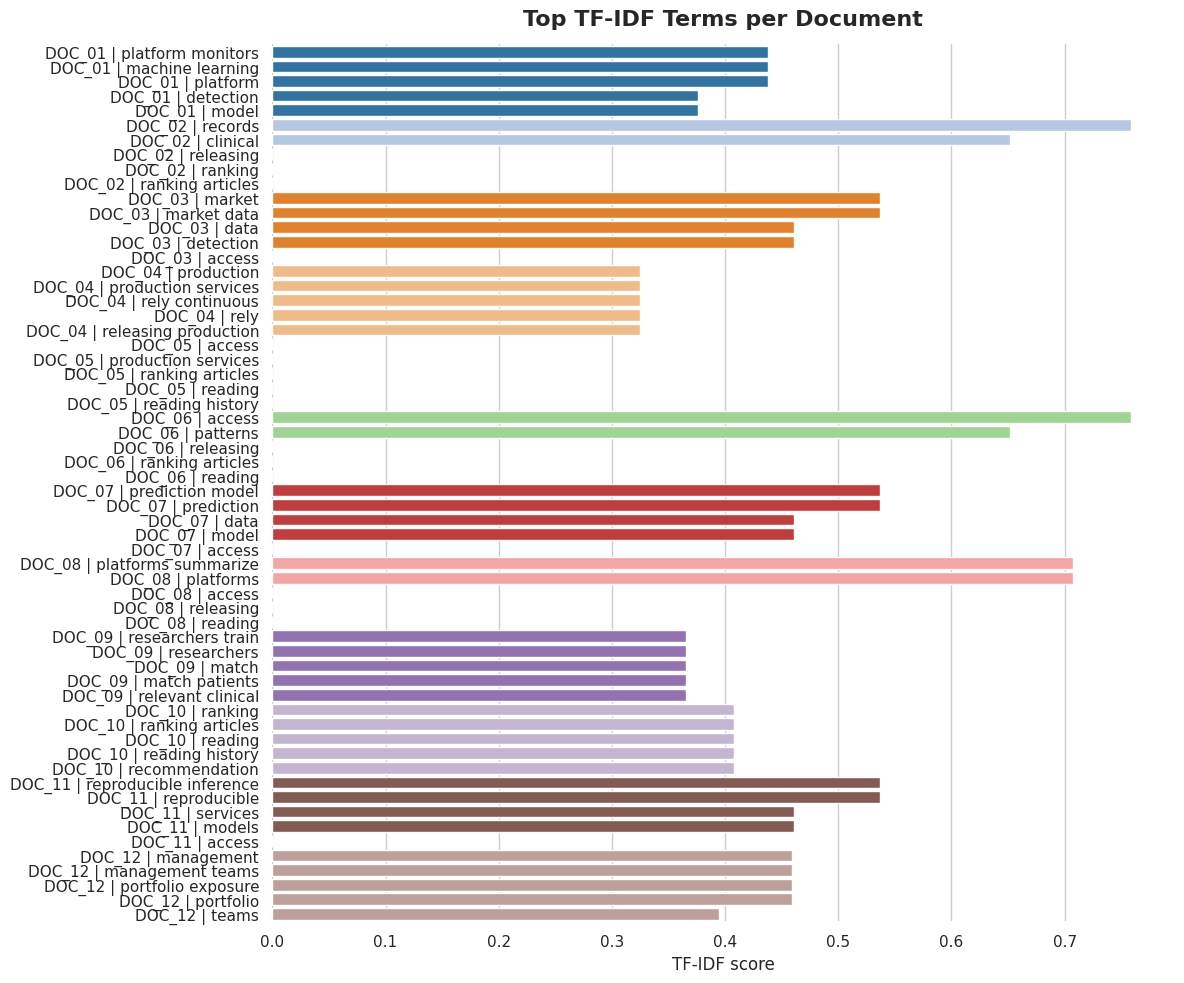

In [11]:
plot_terms_df = top_terms_df.copy()
plot_terms_df["label"] = (
    plot_terms_df["document_id"] + " | " + plot_terms_df["term"]
)

plt.figure(figsize=(12, 10))
ax = sns.barplot(
    data=plot_terms_df,
    x="tfidf_score",
    y="label",
    hue="document_id",
    dodge=False,
    palette="tab20",
)
ax.set_title("Top TF-IDF Terms per Document", fontsize=16, weight="bold", pad=14)
ax.set_xlabel("TF-IDF score", fontsize=12)
ax.set_ylabel("")
ax.legend_.remove()
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

## Similarity Search

Once documents are represented as vectors, we can measure similarity between them. A common metric is **cosine similarity**, which compares the angle between vectors rather than their absolute magnitude.

Cosine similarity is especially common for sparse text vectors because it works well when documents vary in length.

In [12]:
similarity_matrix = cosine_similarity(tfidf_matrix)

similarity_df = pd.DataFrame(
    similarity_matrix,
    index=corpus_df["document_id"],
    columns=corpus_df["document_id"],
)

display(similarity_df.round(3))

document_id,DOC_01,DOC_02,DOC_03,DOC_04,DOC_05,DOC_06,DOC_07,DOC_08,DOC_09,DOC_10,DOC_11,DOC_12
document_id,,,,,,,,,,,,
DOC_01,1.000,0.000,0.173,0.000,0.0,0.245,0.173,0.0,0.000,0.0,0.000,0.00
DOC_02,0.000,1.000,0.000,0.000,0.0,0.000,0.000,0.0,0.205,0.0,0.000,0.00
DOC_03,0.173,0.000,1.000,0.000,0.0,0.000,0.212,0.0,0.000,0.0,0.000,0.00
DOC_04,0.000,0.000,0.000,1.000,0.0,0.000,0.000,0.0,0.000,0.0,0.129,0.11
DOC_05,0.000,0.000,0.000,0.000,0.0,0.000,0.000,0.0,0.000,0.0,0.000,0.00
DOC_06,0.245,0.000,0.000,0.000,0.0,1.000,0.000,0.0,0.000,0.0,0.000,0.00
DOC_07,0.173,0.000,0.212,0.000,0.0,0.000,1.000,0.0,0.000,0.0,0.000,0.00
DOC_08,0.000,0.000,0.000,0.000,0.0,0.000,0.000,1.0,0.000,0.0,0.000,0.00
DOC_09,0.000,0.205,0.000,0.000,0.0,0.000,0.000,0.0,1.000,0.0,0.145,0.00


## Visualization: Document similarity matrix

The diagonal values are always `1.0` because each document is identical to itself. Off-diagonal values reveal which documents share important vocabulary.

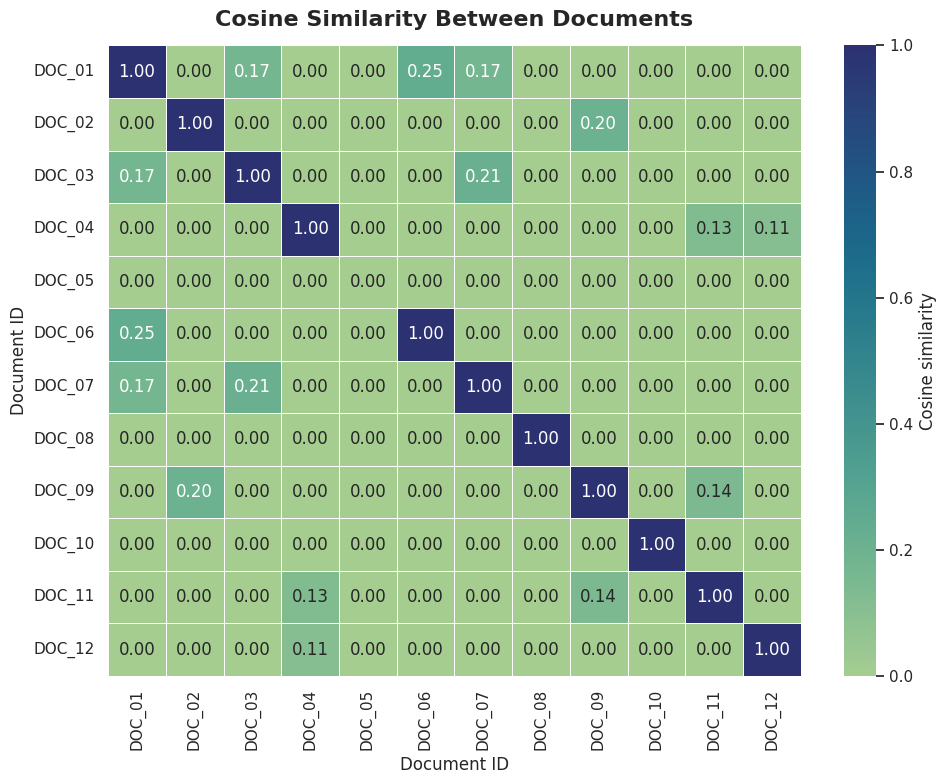

In [13]:
plt.figure(figsize=(10, 8))
ax = sns.heatmap(
    similarity_df,
    cmap="crest",
    vmin=0,
    vmax=1,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Cosine similarity"},
)
ax.set_title("Cosine Similarity Between Documents", fontsize=16, weight="bold", pad=14)
ax.set_xlabel("Document ID", fontsize=12)
ax.set_ylabel("Document ID", fontsize=12)
plt.tight_layout()
plt.show()

## Mini Search Engine

The same TF-IDF vectorizer can transform a user query into the corpus feature space. We can then compare the query vector to each document vector and return the most similar documents.

This is the core idea behind a simple lexical search engine.

In [14]:
def search(query, top_k=5):
    """Return the top-k most similar documents for a text query."""
    query_tokens = preprocess_text(query)
    normalized_query = " ".join(query_tokens)
    query_vector = tfidf_vectorizer.transform([normalized_query])
    scores = cosine_similarity(query_vector, tfidf_matrix).ravel()
    top_indices = np.argsort(scores)[::-1][:top_k]

    results = corpus_df.loc[top_indices, ["document_id", "text"]].copy()
    results["similarity_score"] = scores[top_indices]
    return results[["document_id", "similarity_score", "text"]].reset_index(drop=True)

In [15]:
search_results = search(
    "detect unusual financial transactions and fraud patterns",
    top_k=5,
)

display(search_results.style.format({"similarity_score": "{:.3f}"}))

,document_id,similarity_score,text
0,DOC_06,0.652,Cybersecurity tools analyze authentication logs to detect compromised accounts and unusual access patterns.
1,DOC_01,0.376,A machine learning platform monitors model drift and retrains fraud detection pipelines when transaction patterns change.
2,DOC_12,0.000,Risk management teams build stress testing dashboards to estimate portfolio exposure under volatile economic scenarios.
3,DOC_11,0.000,"MLOps workflows track experiments, package models, and deploy reproducible inference services to cloud infrastructure."
4,DOC_10,0.000,Recommendation engines personalize news feeds by ranking articles according to user interests and reading history.


In [16]:
search_results = search(
    "clinical language models for patient eligibility and medical records",
    top_k=5,
)

display(search_results.style.format({"similarity_score": "{:.3f}"}))

,document_id,similarity_score,text
0,DOC_02,0.838,"Clinical NLP systems extract medication names, dosages, and adverse events from unstructured electronic health records."
1,DOC_09,0.343,Healthcare researchers train language models to match patients with relevant clinical trials based on eligibility criteria.
2,DOC_11,0.251,"MLOps workflows track experiments, package models, and deploy reproducible inference services to cloud infrastructure."
3,DOC_12,0.000,Risk management teams build stress testing dashboards to estimate portfolio exposure under volatile economic scenarios.
4,DOC_10,0.000,Recommendation engines personalize news feeds by ranking articles according to user interests and reading history.


## Discussion

### Advantages

TF-IDF remains useful because it is:

- **simple**: easy to implement, debug, and explain,
- **fast**: efficient for small and medium-scale sparse text problems,
- **interpretable**: feature names directly map to words or phrases,
- **strong for lexical matching**: effective when users search with exact or near-exact terminology.

### Limitations

TF-IDF also has important limitations:

- it does not understand word meaning,
- it cannot reliably match synonyms such as `doctor` and `physician`,
- it ignores deeper context and sentence structure,
- it can be brittle when queries use different vocabulary from the documents,
- it often produces very high-dimensional sparse vectors.

### When TF-IDF fails

TF-IDF tends to fail when semantic similarity matters more than exact word overlap. For example, a query about `reducing hospital readmission risk` may not match a document about `predicting patient discharge outcomes` if the two texts do not share enough vocabulary.

### Why embeddings replaced TF-IDF in many NLP systems

Modern embeddings represent text as dense vectors learned from large datasets. Unlike TF-IDF, embeddings can capture semantic relationships between words, phrases, and documents. This makes them more effective for:

- semantic search,
- question answering,
- recommendation systems,
- retrieval-augmented generation,
- multilingual and cross-domain matching.

TF-IDF is still valuable, especially as a transparent baseline and for lexical search. In many production systems, TF-IDF or BM25 is combined with embeddings in a hybrid retrieval pipeline.

## Final Summary

In this notebook, we built a complete TF-IDF workflow:

1. created a realistic multi-domain text corpus,
2. implemented simple preprocessing,
3. compared Bag of Words with TF-IDF,
4. tuned `TfidfVectorizer` with `max_features`, `ngram_range`, and `stop_words`,
5. visualized term importance with professional heatmaps and bar charts,
6. computed document similarity with cosine similarity,
7. implemented a small search function over the corpus,
8. discussed where TF-IDF works well and where embedding-based methods are stronger.

The key takeaway: **TF-IDF is a strong, interpretable lexical baseline, but modern NLP systems often use embeddings when semantic understanding is required.**